In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# load the data
data = pd.read_csv("/content/Reviews.csv")
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
print(data.columns)

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB
None


<Axes: xlabel='Score'>

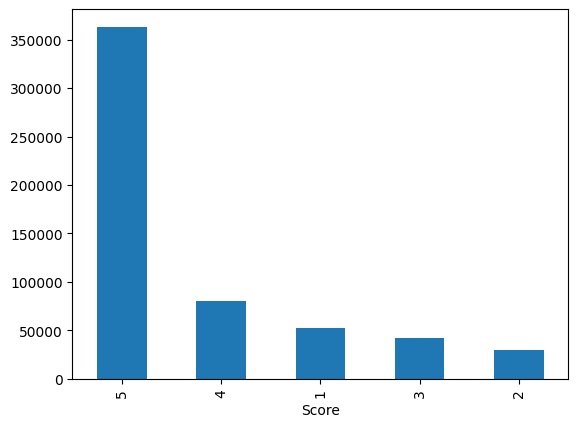

In [ ]:
data['Score'].value_counts().plot(kind='bar')

In [ ]:

# drop rows with score = 3
df = data.drop(data[data['Score'] == 3].index)
df['Score'].value_counts()

,count
Score,
5,363122
4,80655
1,52268
2,29769


In [ ]:
# converting score into binary feature
df['Score'] = df['Score'].apply(lambda x: 1 if x<3 else 0)

## negative review = 1
## positive review = 0


<Axes: xlabel='Score'>

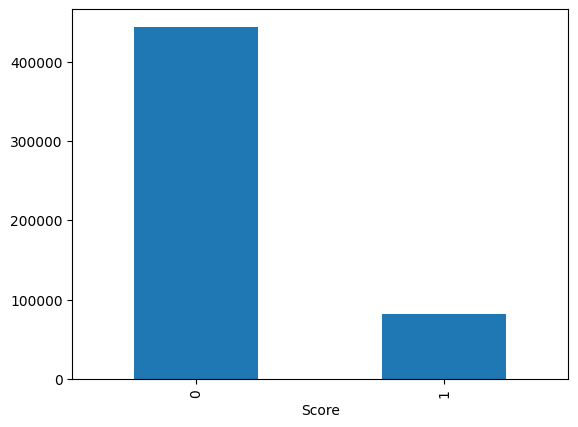

In [ ]:
df['Score'].value_counts().plot(kind='bar')

## showing a imbalanced dataset

In [ ]:
## keeping all the necessary columns
df = df[['Summary','Score','Text']]
df.head()

,Summary,Score,Text
0,Good Quality Dog Food,0,I have bought several of the Vitality canned d...
1,Not as Advertised,1,Product arrived labeled as Jumbo Salted Peanut...
2,"""Delight"" says it all",0,This is a confection that has been around a fe...
3,Cough Medicine,1,If you are looking for the secret ingredient i...
4,Great taffy,0,Great taffy at a great price. There was a wid...


In [ ]:
# checking the null values
df.isnull().sum()

# droping the null values
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Summary,0
Score,0
Text,0


In [ ]:
# text preprocessing

# lowering the characters
df['Text'] = df['Text'].str.lower()

import re
df['Text'] = df['Text'].apply(
    lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x)  # remove URLs
)
df['Text'] = df['Text'].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)  # remove special characters/numbers
)
df['Text'] = df['Text'].apply(
    lambda x: re.sub(r'\s+', ' ', x).strip()  # remove extra spaces
)

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return " ".join([word for word in word_tokenize(text.lower()) if word not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
def lemetize_words(text) :
    return " ".join([lemmatizer.lemmatize(text) for text in text.split()])

In [ ]:
nltk.download('wordnet')
df['Text'] = df['Text'].apply(lambda x:remove_stopwords(x))
df['Text'] = df['Text'].apply(lambda x:lemetize_words(x))

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# train-test-split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df['Text'],df['Score'],test_size=0.2,stratify=df['Score'])

In [ ]:
y_test.head()

,Score
198252,0
449006,0
456965,0
154122,1
278878,0


In [ ]:
# tfidf vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print(X_train_tfidf.shape)
print(type(X_train_tfidf))

(420631, 8000)
<class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=100,
        class_weight="balanced",
        solver='saga',
        n_jobs=-1
    ),

    "Multinomial NB": MultinomialNB(),

}

In [ ]:
sample_size = 120000  # try 100k–150k

idx = np.random.choice(X_train_tfidf.shape[0], sample_size, replace=False)

X_train_sample = X_train_tfidf[idx]
y_train_sample = y_train.iloc[idx]

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
results = []
for name,model in models.items():

    #train
    model.fit(X_train_sample, y_train_sample)

    # predict
    y_pred = model.predict(X_test_tfidf)

    # metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "F1 Score": round(f1, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4)
    })

In [ ]:
results_df  = pd.DataFrame(results)
results_df.sort_values(by='F1 Score',ascending=False)

results_df

,Model,Accuracy,F1 Score,Precision,Recall
0,Logistic Regression,0.9053,0.9112,0.9256,0.9053
1,Multinomial NB,0.8968,0.8784,0.8972,0.8968


In [ ]:
# based on the above logistic regressin peforms better
lr=LogisticRegression(
        max_iter=100,
        class_weight="balanced",
        solver='saga',
        n_jobs=-1
    )
# train
lr.fit(X_train_tfidf,y_train)

# predict
y_pred = model.predict(X_test_tfidf)

    # metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")

print(acc)
print(f1)
print(precision)
print(recall)

0.8967648681032351
0.8783505175952594
0.8972372207691713
0.8967648681032351


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94     88756
           1       0.90      0.38      0.53     16402

    accuracy                           0.90    105158
   macro avg       0.90      0.69      0.74    105158
weighted avg       0.90      0.90      0.88    105158



### for imbalanced dataset , the default 0.5 value is not optimal:


In [ ]:
# insted of hard predictions predict the probablites
probs = lr.predict_proba(X_test_tfidf)[:, 1]

In [ ]:
thresholds = np.arange(0.2, 0.8, 0.02)

best_t = 0.5
best_f1 = 0

for t in thresholds:
    y_pred_t = (probs >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t, pos_label=1)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best class-1 F1:", best_f1)

Best threshold: 0.7199999999999998
Best class-1 F1: 0.798655905913414


In [ ]:
y_pred_best = (probs >= best_t).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     88756
           1       0.79      0.81      0.80     16402

    accuracy                           0.94    105158
   macro avg       0.88      0.89      0.88    105158
weighted avg       0.94      0.94      0.94    105158



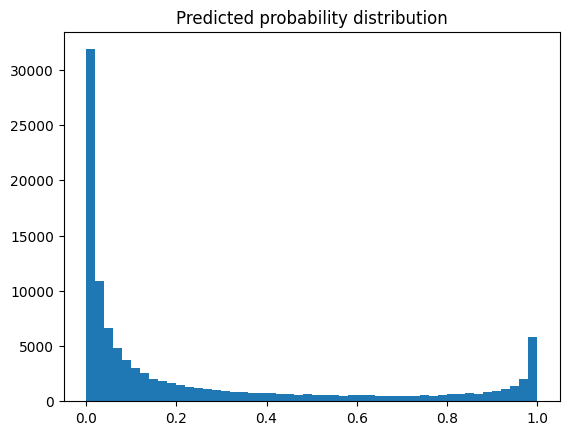

In [ ]:
plt.hist(probs, bins=50)
plt.title("Predicted probability distribution")
plt.show()

In [ ]:
import pickle

# save model
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(lr, f)

# save tfidf
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)